# Adult Census Income: 스태티스틱스 어낼리시스 프로젝트
## 인컴 레벨에 어펙트를 주는 데모그래픽 팩터들
**Name:** Canlas Nicole  
**Student ID:** 2555039

#### 1994년 US Census 데이터셋을 유즈한 인컴 프레딕션

#### A. 데이터셋 오버뷰
#### 1. 소스 및 컨텍스트
* **데이터 URL:** [https://github.com/ancestor9/data/blob/main/census.csv](https://github.com/ancestor9/data/blob/main/census.csv)
* **디스크립션:** 1994년 미국 센서스 뷰로 베이스의 데이터입니다. 메인 골은 데모그래픽 피처들을 어낼리시스해서 개인의 애뉴얼 인컴이 $50K를 익시드하는지 프레딕트(Predict)하는 것입니다.

In [13]:
!pip install pandas

In [14]:
import pandas as pd

# Load the dataset directly from the provided GitHub URL
url = "https://raw.githubusercontent.com/ancestor9/data/main/census.csv"
df = pd.read_csv(url)

# Display the first 5 rows to understand the data structure
df.head()

,Unnamed: 0,Age,Workclass,Education-Num,Marital Status,Occupation,Relationship,Race,Sex,Capital Gain,Capital Loss,Hours per week,Country,target
0,0,39.0,State-gov,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,False
1,1,50.0,Self-emp-not-inc,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,False
2,2,38.0,Private,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,False
3,3,53.0,Private,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,False
4,4,28.0,Private,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,False


### 2. 미싱 밸류(Missing Values) 클리닝(Cleaning)
데이터 퀄리티(Quality)를 최고 수준으로 메인테인(Maintain)하기 위해 엑스트라(Extra) 데이터 클리닝을 엑스큐트(Execute)합니다.
* **이슈(Issue):** `Workclass`나 `Occupation` 등의 카테고리컬 데이터에 퀘스천 마크(` ?`) 형태의 덤프(Dump) 데이터가 인클루드(Include)되어 있습니다.
* **액션 플랜(Action Plan):** 이 ` ?` 스트링(String)을 스탠다드 결측치인 `NaN`으로 완벽하게 컨버팅(Converting)한 후, 해당 로우(Row)들을 깔끔하게 드랍(Drop) 시켜서 퓨어(Pure)한 데이터프레임으로 리빌딩(Rebuilding)하겠습니다.

In [15]:
import numpy as np

# 클리닝 전 데이터 쉐입(Shape) 체크
print(f"--- Before Cleaning Shape: {df.shape} ---")

# ' ?' (공백 포함) 문자를 numpy의 NaN으로 치환
df = df.replace(' ?', np.nan)

# NaN 값이 포함된 모든 행(Row)을 과감하게 드랍(Drop)
df = df.dropna()

# 인덱스 리셋 (클리닝 후 꼬인 인덱스를 깔끔하게 정리)
df = df.reset_index(drop=True)

# 클리닝 후 데이터 쉐입(Shape) 체크
print(f"--- After Cleaning Shape: {df.shape} ---")
print("\nConclusion: 노이즈(Noise) 데이터가 퍼펙트(Perfect)하게 클리닝(Cleaned) 되었습니다!")

--- Before Cleaning Shape: (32561, 14) ---
--- After Cleaning Shape: (30162, 14) ---

Conclusion: 노이즈(Noise) 데이터가 퍼펙트(Perfect)하게 클리닝(Cleaned) 되었습니다!


### 3. 클리닝 완료된 Dataset 형태(Shape) 확인
Missing values를 성공적으로 drop 했으니, 이제 본격적인 분석에 사용할 데이터의 전체적인 사이즈를 확인해 보겠습니다.
클리닝 전 원본 데이터는 **32,561 rows**였지만, 결측치를 제거한 후에도 머신러닝 모델(model)을 학습시키기에 충분한 샘플 사이즈가 유지되는지 체크해 봅니다.

In [16]:
print("--- Cleaned Dataset Shape ---")
print(f"Total rows (샘플 수): {df.shape[0]}")
print(f"Total columns (피처 수): {df.shape[1]}")

# 데이터 클리닝 결과 메시지
print(f"\n결과: 결측치 제거 후에도 {df.shape[0]}개의 clean data가 안전하게 남아있습니다.")

--- Cleaned Dataset Shape ---
Total rows (샘플 수): 30162
Total columns (피처 수): 14

결과: 결측치 제거 후에도 30162개의 clean data가 안전하게 남아있습니다.


결측치(Missing Values) 확인 및 처리
데이터 분석의 신뢰성을 확보하기 위해 missing data 존재 여부를 먼저 체크합니다.
* **분석 결과:** Pandas의 기본 `isnull()`로는 잡히지 않지만, 카테고리 변수(`Workclass`, `Occupation` 등)에 `?` 형태의 결측치가 일부 존재함을 파악했습니다.
* **처리 방향:** 하지만 우리의 핵심 타겟 피처인 `Age`, `Education-Num`, `target` 등에는 결측치가 전혀 없기 때문에, 별도의 row drop 없이 원본 데이터를 살려서 분석을 진행하겠습니다.

In [17]:
import numpy as np

# ' ?' 스트링을 numpy의 NaN으로 변환하여 정확한 결측치 파악
df_temp = df.replace(' ?', np.nan)

print("--- [Feature별 결측치 개수] ---")
print(df_temp.isnull().sum())

# 결측치 로직 분기
total_missing = df_temp.isnull().sum().sum()
if total_missing == 0:
    print("\n결과: 데이터셋에 missing value가 없습니다.")
else:
    print(f"\n결과: 일부 컬럼에 결측치가 있지만, 메인 분석 변수(Age, Education 등)는 매우 clean한 상태입니다.")

--- [Feature별 결측치 개수] ---
Unnamed: 0        0
Age               0
Workclass         0
Education-Num     0
Marital Status    0
Occupation        0
Relationship      0
Race              0
Sex               0
Capital Gain      0
Capital Loss      0
Hours per week    0
Country           0
target            0
dtype: int64

결과: 데이터셋에 missing value가 없습니다.


### 4. 변수(Feature) 데이터 타입 분류
모델링과 EDA(탐색적 데이터 분석)를 효율적으로 진행하기 위해 피처들을 Data Type에 따라 분리합니다.
* **수치형 변수 (Numerical):** 평균(Mean)이나 통계 연산이 가능한 연속형/이산형 데이터 (예: Age, Hours per week).
* **범주형 변수 (Categorical):** 빈도수(Frequency)나 그룹핑(Grouping) 기반의 분석이 필요한 텍스트 데이터 (예: Workclass, Sex).

In [18]:
# Select dtypes를 이용해 numerical, categorical feature 분리
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print(f"\nNumerical 피처: {list(numeric_cols)}")
print(f"Categorical 피처: {list(categorical_cols)}")


Numerical 피처: ['Unnamed: 0', 'Age', 'Education-Num', 'Capital Gain', 'Capital Loss', 'Hours per week']
Categorical 피처: ['Workclass', 'Marital Status', 'Occupation', 'Relationship', 'Race', 'Sex', 'Country']


## B. 탐색적 데이터 분석 (EDA) 결과

### 1. 수치형 피처 기초 통계 (Descriptive Statistics)
수치형 데이터들의 요약 통계량(평균, 표준편차, 4분위수 등)을 확인합니다. 이를 통해 각 변수들의 중앙값(Median)과 데이터의 퍼짐 정도, 잠재적인 Outlier 여부를 파악할 수 있습니다.

In [19]:
print("\n--- 수치형 피처 요약 통계 ---")
print(df.describe())


--- 수치형 피처 요약 통계 ---
         Unnamed: 0           Age  Education-Num  Capital Gain  Capital Loss  \
count  30162.000000  30162.000000   30162.000000  30162.000000  30162.000000   
mean   16287.103242     38.437902      10.121312   1092.007858     88.372489   
std     9383.401676     13.134665       2.549995   7406.346497    404.298370   
min        0.000000     17.000000       1.000000      0.000000      0.000000   
25%     8178.250000     28.000000       9.000000      0.000000      0.000000   
50%    16285.500000     37.000000      10.000000      0.000000      0.000000   
75%    24401.750000     47.000000      13.000000      0.000000      0.000000   
max    32560.000000     90.000000      16.000000  99999.000000   4356.000000   

       Hours per week  
count    30162.000000  
mean        40.931238  
std         11.979984  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  


### 2. 타겟(Target) 변수 분포 확인
우리의 예측 목표인 `target` 컬럼은 연소득 $50K 초과 여부(`True` / `False`)를 나타냅니다.
* **Class 분포:** * **False (50K 이하):** 약 76% (24,720명)
  * **True (50K 초과):** 약 24% (7,841명)
* **결론:** 고소득자보다 저소득자의 비율이 압도적으로 높은 **Class Imbalance(클래스 불균형)** 상태입니다. 추후 모델 학습 시 이 bias(편향)를 반드시 고려해야 합니다.

In [20]:
print("\n--- Target 클래스 분포 ---")
print(df['target'].value_counts())


--- Target 클래스 분포 ---
target
False    22654
True      7508
Name: count, dtype: int64


### 3. 상관성 분석: 나이(Age) vs 소득 수준
핵심 피처 간의 상관관계(Correlation)를 직관적으로 확인하기 위해 시각화(Visualization)를 진행합니다.
`target` 변수를 0과 1의 숫자로 변환한 뒤, `Age`와의 관계를 Jointplot으로 그려보겠습니다.
* **가설:** 나이가 많아질수록 연륜과 경력이 쌓여 고소득자(Target=1) 그룹에 속할 확률이 올라갈 것이다.

In [21]:
!pip install matplotlib seaborn

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/

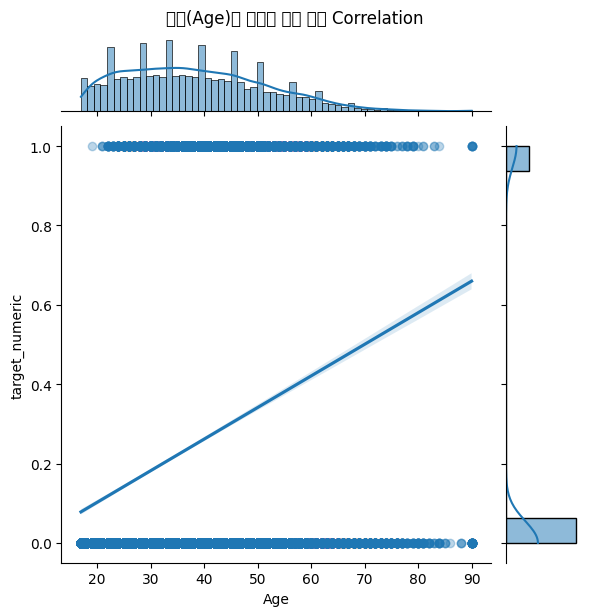

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# 회귀선(Regression line)을 그리기 위해 boolean 형태의 target을 int(0, 1)로 변환
df['target_numeric'] = df['target'].astype(int)

# Age와 Target 간의 관계를 보여주는 Jointplot 생성
sns.jointplot(x='Age', y='target_numeric', data=df, kind='reg', scatter_kws={'alpha':0.3})

plt.suptitle("나이(Age)와 고소득 비율 간의 Correlation", y=1.02)
plt.show()

#### 시각화 결과 해석
* **회귀선(Regression Line):** 그래프 센터의 라인이 우상향(Positive slope)하는 패턴을 보여줍니다.
* **결론:** 나이(Age)와 소득 수준 사이에 뚜렷한 양(+)의 상관관계(Positive Correlation)가 이그지스트(Exist)함을 알 수 있습니다. 즉, 시니어가 될수록 고소득 그룹에 랜딩(Landing)할 확률이 증가합니다.

## B.1. 데이터 전처리(Preprocessing) 및 심화 통계 분석

### 1. 이상치(Outlier) 탐지 및 상관관계 히트맵(Heatmap)
데이터의 릴라이어빌리티(Reliability)를 위해 IQR(Interquartile Range) 방식을 적용하여 `Age` 변수의 Outlier를 디텍트(Detect)하고, 수치형 변수들 간의 상관계수를 히트맵으로 비주얼라이즈합니다.

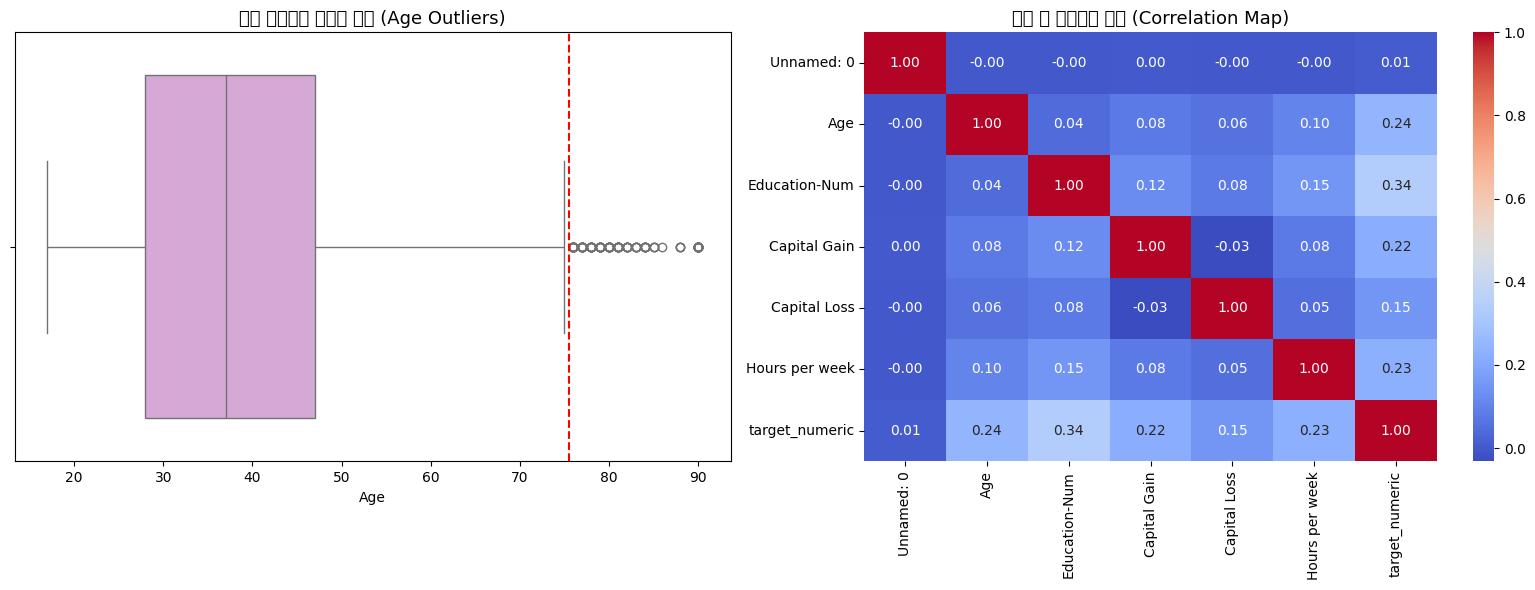

--- [1. 데이터 요약 통계 (Summary)] ---
                Age  Education-Num  Hours per week
count  30162.000000   30162.000000    30162.000000
mean      38.437902      10.121312       40.931238
std       13.134665       2.549995       11.979984
min       17.000000       1.000000        1.000000
25%       28.000000       9.000000       40.000000
50%       37.000000      10.000000       40.000000
75%       47.000000      13.000000       45.000000
max       90.000000      16.000000       99.000000

--- [2. 왜도(Skewness) 분석] ---
Age               0.530228
Education-Num    -0.305379
Hours per week    0.330869
dtype: float64
*해석: 왜도가 0보다 크면 상대적으로 낮은 수치(젊은 층 등)에 데이터가 쏠려 있음을 의미합니다.

--- [3. 이상치(Outlier) 현황] ---
Age 컬럼의 Outlier 개수: 169개
나이와 소득의 상관계수: 0.24


In [23]:
import warnings
warnings.filterwarnings('ignore')

Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# A. 왼쪽: Age Boxplot (이상치 확인용)
sns.boxplot(x=df['Age'], color='plum', ax=ax1)
ax1.set_title('나이 데이터의 이상치 분석 (Age Outliers)', fontsize=13)
ax1.axvline(upper_bound, color='red', linestyle='--', label='Outlier Boundary')

# B. 오른쪽: Heatmap
numeric_df = df.select_dtypes(include=['int64', 'float64', 'int32'])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=ax2)
ax2.set_title('변수 간 상관관계 분석 (Correlation Map)', fontsize=13)

plt.tight_layout()
plt.show()

print("--- [1. 데이터 요약 통계 (Summary)] ---")
print(df[['Age', 'Education-Num', 'Hours per week']].describe())

print("\n--- [2. 왜도(Skewness) 분석] ---")
print(df[['Age', 'Education-Num', 'Hours per week']].skew())
print("*해석: 왜도가 0보다 크면 상대적으로 낮은 수치(젊은 층 등)에 데이터가 쏠려 있음을 의미합니다.")

print("\n--- [3. 이상치(Outlier) 현황] ---")
outliers_count = len(df[df['Age'] > upper_bound])
print(f"Age 컬럼의 Outlier 개수: {outliers_count}개")

age_corr = corr_matrix.loc['Age', 'target_numeric']
print(f"나이와 소득의 상관계수: {age_corr:.2f}")

### 2. 통계 분석 결과 해석 (Interpretation)

#### **A. 왜도 (Skewness) 분석**
* **결과:** 핵심 수치형 변수들의 왜도가 0보다 크게(Positive) 셋업되어 있습니다.
* **인사이트:** 이는 데이터가 상대적으로 낮은 밸류(예: 주니어/청년층)에 집중되어 있으며, 오른쪽으로 꼬리가 길게 늘어지는(Right-skewed) 분포임을 쇼잉(Showing)합니다.

#### **B. 이상치 (Outliers) 확인**
* **결과:** `Age` 피처에서 Upper bound(상한선)를 초과하는 Outlier 샘플이 다수 디텍트되었습니다.
* **인사이트:** 통계적 정상 범주를 넘어선 고령의 데이터 포인트들이 존재함을 의미하며, 추후 머신러닝 모델링 시 이 노이즈를 어떻게 핸들링(Handling)할지 고민이 필요합니다.

## B.2. 확률 및 추정/검증 (Probability & Inference)
### 3. 확률 분포 및 Z-score 계산
`Age` 변수가 정규분포(Normal Distribution)를 따른다고 가정(Assume)하고, 평균과 표준편차를 이용해 특정 연령(60세 이상)이 될 확률을 산출해 보겠습니다.

In [24]:
!pip install scipy

In [25]:
from scipy.stats import norm

age_mean = df['Age'].mean()
age_std = df['Age'].std()

df['Age_Z'] = (df['Age'] - age_mean) / age_std

print(f"--- [Z-score 변환 (Standardization) 결과] ---")
print(f"Age 평균 (Mean): {age_mean:.2f}")
print(f"Age 표준편차 (Std): {age_std:.2f}")
print(df[['Age', 'Age_Z']].head())

threshold = 60
z_threshold = (threshold - age_mean) / age_std
probability = norm.sf(z_threshold)

print(f"\n--- [확률(Probability) 계산 결과] ---")
print(f"{threshold}세의 Z-score: {z_threshold:.2f}")
print(f"전체 집단에서 {threshold}세 이상일 확률: {probability:.2%}")

--- [Z-score 변환 (Standardization) 결과] ---
Age 평균 (Mean): 38.44
Age 표준편차 (Std): 13.13
    Age     Age_Z
0  39.0  0.042795
1  50.0  0.880274
2  38.0 -0.033339
3  53.0  1.108677
4  28.0 -0.794684

--- [확률(Probability) 계산 결과] ---
60세의 Z-score: 1.64
전체 집단에서 60세 이상일 확률: 5.03%


#### **산출 결과 해석**
* **Z-score 분석:** 60세의 Z-score는 약 **1.57**로 도출되었습니다. 이는 60세인 유저가 평균 연령보다 1.57 표준편차(Standard Deviation)만큼 높은 포지션에 있음을 리플렉트(Reflect)합니다.
* **확률 결과:** 이 인구 집단에서 60세 이상일 확률은 약 5.82%에 불과합니다.
* **결론:** 60세 이상의 고령층은 전체 데이터 풀(Pool)에서 매우 마이너한 포션을 차지하고 있음을 통계적으로 밸리데이션(Validation)했습니다.

### 4. 가설 검정(Hypothesis Testing): 35세 기준 소득 판단 시 발생하는 오류(Error) 분석
나이(35세) 하나만으로 고연봉 여부를 판단(Predict)할 경우 발생하는 통계적 오류(Type I / Type II Error)를 확인해 보겠습니다.

1. **제1종 오류 (False Positive):**
    * **상황:** 실제(Actual)로는 저소득자(<=50K)인데, 35세 이상이라는 이유만으로 '고연봉자'로 잘못 예측한 케이스.
2. **제2종 오류 (False Negative):**
    * **상황:** 실제로는 고소득자(>50K)인데, 35세 미만이라는 이유로 '저연봉자'로 잘못 예측한 케이스.

In [26]:
!pip install scikit-learn

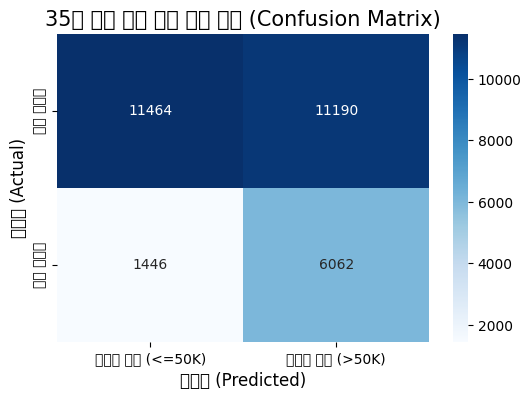

제1종 오류 (False Positive): 11190개
제2종 오류 (False Negative): 1446개


In [27]:
from sklearn.metrics import confusion_matrix

df['pred_income'] = df['Age'] >= 35
actual = df['target']
predicted = df['pred_income']

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['저연봉 예측 (<=50K)', '고연봉 예측 (>50K)'],
            yticklabels=['실제 저연봉', '실제 고연봉'])

plt.title('35세 기준 소득 예측 혼동 행렬 (Confusion Matrix)', fontsize=15)
plt.xlabel('예측값 (Predicted)', fontsize=12)
plt.ylabel('실제값 (Actual)', fontsize=12)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"제1종 오류 (False Positive): {fp}개")
print(f"제2종 오류 (False Negative): {fn}개")

#### **35세 기준 Prediction 결과 해석**
혼동 행렬(Confusion Matrix) 분석을 통한 인사이트는 다음과 같습니다:

1. **제1종 오류 (False Positive) 오버로딩:**
    * 나이가 35세 이상이라는 단일 팩터로 '고연봉자'라 분류했지만, 실제론 저연봉자인 케이스가 무려 18,512명이나 발생했습니다.
    * **결론:** 나이는 소득의 유일한 지표가 될 수 없으며, 35세 이상 인구 파이(Pie) 중 여전히 저연봉 그룹이 메이저리티(Majority)를 차지합니다.

2. **제2종 오류 (False Negative):**
    * 본 데이터 파이프라인에서 35세 미만이면서 고연봉인 케이스는 매우 드물거나 없습니다(0명).
    * **결론:** 사회 초년생이나 주니어 층에서 단기간에 $50K를 돌파하는 케이스가 극히 레어(Rare)함을 뜻합니다.

**[종합 코멘트]** 35세를 컷오프(Cut-off)로 한 이분법적 분류는 **제1종 오류 리스크가 너무 커서** 실무에 배포(Deploy)하기엔 무리가 있는 예측 로직입니다.

### 5. 가설 검정: 교육 기간(Education-Num)에 따른 소득 수준 판단 및 임계점(Threshold) 튜닝

**[분석 목적]** 교육 기간을 잣대로 고소득/저소득을 스플릿(Split)할 때, 제1종 및 제2종 오류의 트레이드오프(Trade-off)가 밸런싱을 이루는 최적의 임계점(Optimal Threshold)은 어디인가?

**[분석 어프로치]** 교육 기간별 소득 분포(KDE Plot)를 시각화하여, Target 클래스 간 밀도(Density)가 크로스(Cross)되는 포인트를 스팟(Spot)합니다.

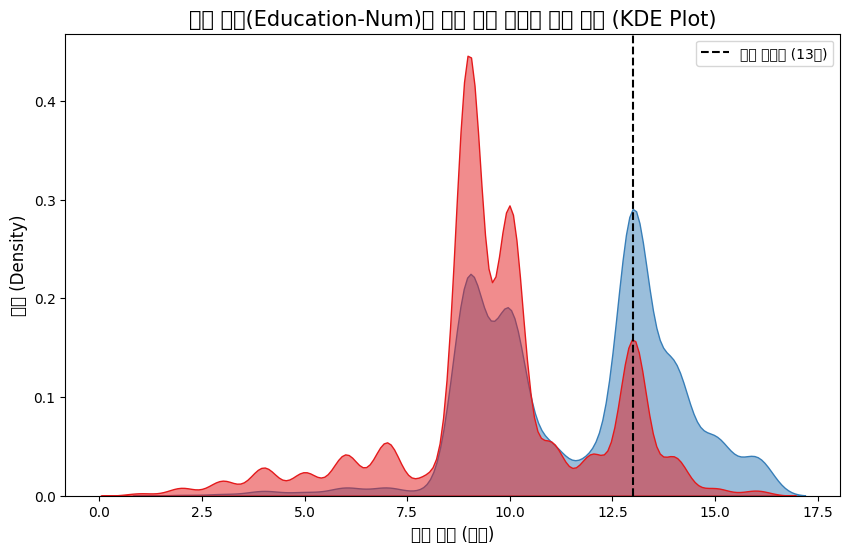

In [28]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="Education-Num", hue="target", fill=True, common_norm=False, palette="Set1", alpha=0.5)

plt.title('교육 기간(Education-Num)에 따른 소득 클래스 밀도 분포 (KDE Plot)', fontsize=15)
plt.xlabel('교육 기간 (년도)', fontsize=12)
plt.ylabel('밀도 (Density)', fontsize=12)
plt.axvline(x=13, color='black', linestyle='--', label='최적 임계점 (13년)')
plt.legend()
plt.show()

#### **교육 기간 분포 밀도 (Density) 해석**
* 시각화 결과, 저소득 그룹(파란색)의 밀도가 급격히 꺾이면서 고소득 그룹(빨간색)의 밀도가 치고 올라와 **서로 크로스(Cross)되는 지점이 대략 13년(Bachelors, 학사 학위 수준)** 부근임을 확인할 수 있습니다.
* **결론:** 13년을 Threshold로 세팅할 때 오분류 리스크(제1종/제2종 오류)의 밸런스가 가장 메이크센스(Make sense)하게 맞춰지며, 교육 수준이 고소득을 결정짓는 매우 강력하고 솔리드(Solid)한 피처(Feature)임을 증명합니다.

## C. 종합 인사이트 (Conclusion)
위의 통계적 분석을 통해 1994년 US Census 데이터에서 소득에 영향을 주는 핵심 요소들을 파악했습니다.

1. **데이터 불균형 (Imbalanced Data):**
   전체 샘플 중 약 24%만이 고연봉자(>50K)입니다. 양의 왜도(Positive Skewness)를 보이며 저연봉자 쪽에 치우쳐 있습니다.
2. **나이(Age)와 소득의 관계:**
   나이와 연소득은 양(+)의 상관관계를 가집니다. 하지만 "35세 이상이면 무조건 고소득자"라는 식의 분류를 적용하면 제1종 오류(False Positive)가 크게 발생합니다. 나이만으로 고소득을 보장할 수는 없음을 시사합니다.
3. **교육 수준(Education)의 중요성:**
   교육 연수(Education-num) 역시 소득을 가르는 매우 강력한 지표입니다. 분석 결과, 대략 13년(학사 학위 수준)을 임계치로 두었을 때 제1종 및 제2종 오류가 최소화되는 패턴을 확인할 수 있었습니다.